In [1]:
import pandas as pd
import numpy as np
import mygene
import gseapy as gp
import os

C:\Users\jiangy5\AppData\Roaming\Python\Python39\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [7]:

from typing import List, Tuple, Optional



def kegg_enrichment_topN_from_uniprot(
    uniprot_list: List[str],
    species: str = "human",
    gene_set: str = "KEGG_2021_Human",   # e.g. "KEGG_2019_Human"
    cutoff: float = 0.05,
    top_n: int = 20,
    outdir: Optional[str] = None,        # folder to save CSV (can be None)
    mapping_filename: Optional[str] = "uniprot_to_symbol_mapping.csv",
    result_filename: str = "kegg_enrichment_topN.csv",
) -> Tuple[Optional[pd.DataFrame], Optional[pd.DataFrame]]:
    """
    Run KEGG enrichment from a UniProt ID list and return top N enriched terms.

    Parameters
    ----------
    uniprot_list : list of str
        List of UniProt accession IDs.
    species : str, default "human"
        Species name for mygene and gseapy (e.g. "human", "mouse").
    gene_set : str, default "KEGG_2021_Human"
        Enrichr KEGG library name, e.g. "KEGG_2019_Human".
    cutoff : float, default 0.05
        Adjusted p-value (FDR) cutoff used by gseapy.
    top_n : int, default 20
        Number of top enriched terms to keep (sorted by Adjusted P-value).
    outdir : str or None, default None
        If not None, save mapping and topN results to this folder.
    mapping_filename : str or None, default "uniprot_to_symbol_mapping.csv"
        If not None and outdir is not None, save UniProt → gene_symbol map.
    result_filename : str, default "kegg_enrichment_topN.csv"
        File name for saving topN enrichment results (inside outdir).

    Returns
    -------
    top_res : pandas.DataFrame or None
        Top N enrichment results (sorted by Adjusted P-value).
    mapping_df : pandas.DataFrame or None
        UniProt → gene_symbol mapping table.
    """

    # 1. Clean UniProt list
    uniprot_list = [str(u) for u in uniprot_list if pd.notna(u)]
    uniprot_list = list(set(uniprot_list))
    if len(uniprot_list) == 0:
        print("No valid UniProt IDs provided.")
        return None, None

    print(f"Number of unique UniProt IDs: {len(uniprot_list)}")

    # 2. UniProt → gene symbol
    mg = mygene.MyGeneInfo()
    print("Mapping UniProt IDs → gene symbols ...")

    query_results = mg.querymany(
        uniprot_list,
        scopes="uniprot",
        fields="symbol,entrezgene",
        species=species,
        as_dataframe=True
    )

    if "notfound" in query_results.columns:
        query_results = query_results[~query_results["notfound"].fillna(False)]

    query_results = query_results.dropna(subset=["symbol"])

    if query_results.empty:
        print("No UniProt IDs mapped to gene symbols.")
        return None, None

    mapping_df = (
        query_results
        .reset_index()
        .groupby("query")["symbol"]
        .first()
        .reset_index()
        .rename(columns={"query": "uniprot_id", "symbol": "gene_symbol"})
    )

    symbol_list = mapping_df["gene_symbol"].dropna().unique().tolist()
    print(f"Mapped to {len(symbol_list)} gene symbols.")

    # 3. Prepare outdir and save mapping if needed
    if outdir is not None:
        os.makedirs(outdir, exist_ok=True)
        if mapping_filename is not None:
            mapping_path = os.path.join(outdir, mapping_filename)
            mapping_df.to_csv(mapping_path, index=False)
            print(f"Mapping saved to {mapping_path}")

    # 4. Run KEGG enrichment (gseapy.enrichr)
    print(f"Running KEGG enrichment using gene set: {gene_set}")

    enr = gp.enrichr(
        gene_list=symbol_list,
        gene_sets=gene_set,
        organism=species.capitalize(),
        outdir=None,      # 不用让 gseapy 自动写一堆东西
        cutoff=cutoff
    )

    res = enr.res2d
    if res is None or res.empty:
        print("No enriched KEGG pathways found.")
        return None, mapping_df

    # 5. Sort and select top N by Adjusted P-value
    if "Adjusted P-value" in res.columns:
        res_sorted = res.sort_values("Adjusted P-value", ascending=True)
    else:
        # fallback: in case column name changed
        res_sorted = res.sort_values(res.columns[2], ascending=True)

    top_res = res_sorted.head(top_n).reset_index(drop=True)

    # Save topN results if requested
    if outdir is not None:
        result_path = os.path.join(outdir, result_filename)
        top_res.to_csv(result_path, index=False)
        print(f"Top {top_n} KEGG enrichment results saved to {result_path}")

    return top_res, mapping_df


In [8]:
from PIL import Image
import matplotlib.pyplot as plt

def plot_kegg_barplot_topN(
    enrichment_df: pd.DataFrame,
    cutoff: float = 0.05,
    top_n: int = 20,
    outpath: Optional[str] = None,           # 输出目录
    plot_filename: str = "kegg_enrichment_topN.png"  # 文件名
) -> None:
    """
    Plot KEGG barplot from an enrichment result DataFrame.

    Parameters
    ----------
    enrichment_df : pandas.DataFrame
        Enrichment result table, e.g. from kegg_enrichment_topN_from_uniprot.
    cutoff : float, default 0.05
        Adjusted p-value cutoff used by gseapy.barplot.
    top_n : int, default 20
        Number of top terms to show in the barplot.
    outpath : str or None, default None
        Directory for saving the barplot figure.
        If None, use current directory.
    plot_filename : str, default "kegg_enrichment_topN.png"
        File name of the barplot.
    """
    if enrichment_df is None or enrichment_df.empty:
        print("enrichment_df is empty, nothing to plot.")
        return

    # 如果没给目录，就用当前目录
    if outpath is None:
        outpath = "."

    # 确保目录存在
    os.makedirs(outpath, exist_ok=True)

    # 完整文件路径 = 目录 + 文件名
    save_path = os.path.join(outpath, plot_filename)

    print(f"Saving KEGG barplot to {save_path}")
    gp.barplot(
        enrichment_df,
        cutoff=cutoff,
        top_term=top_n,
        ofname=save_path
    )
    print("Barplot finished.")
        # --- Display inside Jupyter Notebook ---
    print("Displaying plot in notebook...")
    img = Image.open(save_path)

    plt.figure(figsize=(8, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [4]:
file_path_kegg = r"C:\project8  Robotics and AI enable automation in modern proteomics\files\kegg"
figure_path_kegg = r"C:\project8  Robotics and AI enable automation in modern proteomics\figures\kegg"

In [5]:
file_path= r"C:\project8  Robotics and AI enable automation in modern proteomics\files"

In [11]:
df_filter = pd.read_csv(f'{file_path}\drug_names_replaced_filtered_raw_clean.csv', index_col = 0)
df_filter

,Blue1_QC10,Blue1_QC11,Blue1_QC12,Blue1_QC1,Blue1_QC2,Blue1_QC3,Blue1_QC4,Blue1_QC5,Blue1_QC6,Blue1_QC7,...,Ambroxol_6,Pergolide (mesylate)_6,Liranaftate_6,Efavirenz_6,Saquinavir (mesylate)_6,Remdesivir_6,Azelastine (hydrochloride)_6,Cobicistat_6,Oteseconazole_6,Paritaprevir_6
A0A096LP01,3.706380e+05,4.183620e+05,3.670840e+05,2.721690e+05,2.236970e+05,2.703380e+05,2.713110e+05,3.140880e+05,2.144710e+05,3.247920e+05,...,5.035410e+05,8.795080e+05,9.035980e+05,6.301810e+05,6.148380e+05,3.603660e+05,3.547240e+05,4.706520e+05,4.582960e+05,8.537600e+05
A0A1W2PQ72,2.084300e+04,1.410970e+04,8.611230e+03,2.122080e+04,NaN,NaN,2.149120e+04,1.217190e+04,2.127670e+04,1.587100e+04,...,NaN,1.561010e+04,9.797890e+03,1.336830e+04,7.404120e+03,2.619750e+04,NaN,1.467620e+04,1.506040e+04,8.486690e+03
A0A6Q8PH20,1.587430e+07,1.645540e+07,1.699480e+07,1.797980e+07,1.843980e+07,1.648390e+07,1.798750e+07,1.610600e+07,1.708660e+07,1.741300e+07,...,1.985270e+07,1.961520e+07,2.247230e+07,1.920000e+07,1.919880e+07,1.687800e+07,2.284890e+07,2.042520e+07,2.214370e+07,2.042690e+07
A0A804HLA8,NaN,5.437690e+04,6.360230e+04,3.215350e+05,1.650910e+05,1.060200e+05,1.243900e+05,5.574910e+04,5.649850e+04,NaN,...,3.408030e+05,1.727730e+05,2.014670e+05,5.855050e+04,4.226430e+05,3.935590e+05,3.169930e+05,2.257290e+05,1.997370e+05,2.843250e+05
A0AAG2UWQ9,3.753250e+06,3.820310e+06,3.547970e+06,3.505860e+06,3.922710e+06,3.356580e+06,3.768140e+06,3.205860e+06,3.842290e+06,4.078990e+06,...,4.596370e+06,4.516000e+06,4.636850e+06,4.026500e+06,5.036950e+06,5.946650e+06,4.911380e+06,4.308670e+06,4.128310e+06,4.354510e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cRAP-O77727,2.259780e+07,3.751540e+07,5.810690e+07,4.440570e+07,3.999610e+07,2.611060e+07,3.028790e+07,2.382840e+07,2.013690e+07,2.176710e+07,...,1.164280e+07,9.778120e+06,2.265350e+07,9.800500e+06,9.608400e+06,1.843700e+07,8.680690e+06,1.436950e+07,6.930320e+06,2.512890e+07
cRAP-P00761,2.296830e+09,2.442490e+09,2.369380e+09,4.083190e+09,3.209180e+09,2.264710e+09,2.441790e+09,2.044000e+09,2.297910e+09,2.353510e+09,...,5.030170e+09,2.771690e+09,2.899140e+09,3.045830e+09,3.738340e+09,5.474240e+09,3.878060e+09,3.843600e+09,4.098020e+09,3.130040e+09
cRAP-P02769,3.009900e+08,3.180380e+08,3.211170e+08,2.643880e+08,2.845760e+08,2.918890e+08,2.938820e+08,3.044470e+08,3.092270e+08,3.216960e+08,...,8.992040e+07,1.283640e+08,1.362450e+08,1.490850e+08,1.336430e+08,2.162950e+08,9.931290e+07,9.490300e+07,7.307120e+07,7.703550e+07
cRAP-P12763,5.871560e+08,5.963820e+08,6.115800e+08,5.177850e+08,6.004660e+08,6.145010e+08,6.012420e+08,5.734570e+08,5.935640e+08,6.105860e+08,...,4.204630e+08,6.259050e+08,6.995360e+08,6.337540e+08,6.153630e+08,9.998500e+08,4.316460e+08,3.899230e+08,3.121080e+08,3.263700e+08


In [12]:
# pip install mygene
import mygene
import pandas as pd

mg = mygene.MyGeneInfo()

uniprot_ids = df_filter.index.tolist()

res2 = mg.querymany(
    uniprot_ids,
    scopes='uniprot',
    fields='symbol',
    species='human'
)

df_map = pd.DataFrame(res2)
print(df_map[['query','symbol']])

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
32 input query terms found dup hits:	[('B7ZAQ6', 2), ('P02489', 2), ('P0C0L4', 2), ('P0C0L5', 2), ('P0C0S8', 5), ('P0DMM9', 2), ('P0DMV8'
23 input query terms found no hit:	['A6NKF1', 'A8CG34', 'A8MWD9', 'C4AMC7', 'P01893', 'P57078', 'Q13670', 'Q58FF6', 'Q58FF8', 'Q58FG0',


            query   symbol
0      A0A096LP01   SMIM26
1      A0A1W2PQ72  MSANTD7
2      A0A6Q8PH20     CAST
3      A0A804HLA8    GNG5B
4      A0AAG2UWQ9     NKRF
...           ...      ...
8194  cRAP-O77727      NaN
8195  cRAP-P00761      NaN
8196  cRAP-P02769      NaN
8197  cRAP-P12763      NaN
8198  cRAP-Q58D62      NaN

[8199 rows x 2 columns]


# kegg enrichment 

In [13]:
df_map = df_map.drop_duplicates(subset=['query'])
genes = df_map['symbol'].dropna().tolist()

In [14]:

# choose libraries (you can add/remove)
gene_sets = [
    "KEGG_2021_Human",
    "Reactome_2022",
]

enr_kegg = gp.enrichr(
            gene_list = genes,
            gene_sets = gene_sets,
            organism="human",
            outdir= None,
            cutoff=0.05,   # adjusted p-value cutoff
        )

# results table
res_kegg = enr_kegg.results
print(res_kegg.head())

          Gene_set                                         Term  Overlap  \
0  KEGG_2021_Human                                  Endocytosis  185/252   
1  KEGG_2021_Human                Amyotrophic lateral sclerosis  246/364   
2  KEGG_2021_Human  Protein processing in endoplasmic reticulum  136/171   
3  KEGG_2021_Human                                  Spliceosome  123/150   
4  KEGG_2021_Human                                     Ribosome  127/158   

        P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
0  2.439820e-26      7.758628e-24            0                     0   
1  9.937586e-26      1.543766e-23            0                     0   
2  1.812129e-25      1.543766e-23            0                     0   
3  1.941844e-25      1.543766e-23            0                     0   
4  1.149109e-24      7.308334e-23            0                     0   

   Odds Ratio  Combined Score  \
0    4.108050      242.273437   
1    3.112165      179.170116   
2    5.7611

In [18]:
# res_kegg.to_csv(f'{file_path_kegg}\KEGG_enrich_allgenes.csv')

# plot KEGG enrichment results

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_topN_kegg(
    res,
    N=20,
    gene_set="GO_Cellular_Component_2023",
    term_col="Term",
    fdr_col="Adjusted P-value",
    overlap_col="Overlap",
    drop_go_id=True,
    figsize=(8, 10),
    ticksize = 18,
):
    df = res.copy()

    # filter by gene set library if possible
    if gene_set is not None and "Gene_set" in df.columns:
        df = df[df["Gene_set"] == gene_set].copy()

    # remove trailing "(GO:xxxxxxx)" safely (no regex)
    if drop_go_id and term_col in df.columns:
        df[term_col] = df[term_col].astype(str).str.split(" (GO:", regex=False).str[0]

    # ensure numeric FDR
    if fdr_col not in df.columns:
        raise ValueError(f"Column {fdr_col!r} not found. Available columns: {df.columns.tolist()}")

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df = df.dropna(subset=[fdr_col]).copy()

    # top N by FDR
    df = df.sort_values(fdr_col, ascending=True).head(N).copy()
    df["neglog10_FDR"] = -np.log10(df[fdr_col].clip(lower=1e-300))

    # robust gene count extraction from Overlap like "5/120"
    if overlap_col in df.columns:
        df["Gene_count"] = (
            df[overlap_col]
            .astype(str)
            .str.extract(r"(\d+)\s*/", expand=False)   # get the leading hit count
        )
        df["Gene_count"] = pd.to_numeric(df["Gene_count"], errors="coerce")

    # order so most significant on top
    df = df.sort_values("neglog10_FDR", ascending=True)

    plt.rcParams["font.family"] = "Arial"
    plt.figure(figsize=figsize)
    # ax = sns.barplot(data=df, x="neglog10_FDR", y=term_col)
    ax = sns.scatterplot(
            data=df,
            x="neglog10_FDR",
            y=term_col,
            size="Gene_count",
            sizes=(50, 800),
            # legend=True
            legend="brief"
        )
    
    ax.set_xlabel("-log10(FDR)",fontsize = ticksize)
    ax.set_ylabel("")
    ax.tick_params(axis='x', labelsize=ticksize)
    ax.tick_params(axis='y', labelsize=ticksize)
    # ax.set_title(f"Top {N} GO terms")
    ax.legend(title="Gene count", fontsize=12,title_fontsize=14,)
    # legend = ax.legend(
    # title="Gene count",
    # fontsize=16,
    # title_fontsize=16,
    # frameon=False,
    # bbox_to_anchor=(0.7, 1),
    # loc="upper left"
    # )

    plt.tight_layout()
    plt.show()

    # return df


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

def plot_topN_kegg2(
    res,
    N=20,
    gene_set="GO_Cellular_Component_2023",
    term_col="Term",
    fdr_col="Adjusted P-value",
    overlap_col="Overlap",
    drop_go_id=True,
    figsize=(8, 10),
    ticksize=18,
    size_range=(80, 900),          # 气泡大小范围（面积）
    point_color="#4E79A7",         # muted blue（科研风）
    text_color="gray",
    grid=True,
):
    df = res.copy()

    # filter by gene set library if possible
    if gene_set is not None and "Gene_set" in df.columns:
        df = df[df["Gene_set"] == gene_set].copy()

    # remove trailing "(GO:xxxxxxx)" safely (no regex)
    if drop_go_id and term_col in df.columns:
        df[term_col] = df[term_col].astype(str).str.split(" (GO:", regex=False).str[0]

    # ensure numeric FDR
    if fdr_col not in df.columns:
        raise ValueError(f"Column {fdr_col!r} not found. Available columns: {df.columns.tolist()}")

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df = df.dropna(subset=[fdr_col]).copy()

    # top N by FDR
    df = df.sort_values(fdr_col, ascending=True).head(N).copy()
    df["neglog10_FDR"] = -np.log10(df[fdr_col].clip(lower=1e-300))

    # robust gene count extraction from Overlap like "5/120"
    if overlap_col in df.columns:
        df["Gene_count"] = (
            df[overlap_col].astype(str).str.extract(r"(\d+)\s*/", expand=False)
        )
        df["Gene_count"] = pd.to_numeric(df["Gene_count"], errors="coerce")

    # drop rows with no Gene_count (optional but usually helpful)
    df = df.dropna(subset=["Gene_count"]).copy()

    # ---- order: make most significant on TOP ----
    # most significant = larger -log10(FDR)
    df = df.sort_values("neglog10_FDR", ascending=False).copy()

    # convert y to categorical and preserve order
    df[term_col] = pd.Categorical(df[term_col], categories=df[term_col].tolist(), ordered=True)
    # ---- before plotting: wrap y labels ----
    df[term_col] = df[term_col].astype(str).apply(
        lambda s: "\n".join(textwrap.wrap(s, width=28, break_long_words=False))
    )

    # ---- map Gene_count -> bubble area ----
    gc = df["Gene_count"].astype(float).values
    gc_min, gc_max = np.nanmin(gc), np.nanmax(gc)
    if gc_min == gc_max:
        sizes = np.full_like(gc, np.mean(size_range), dtype=float)
    else:
        sizes = np.interp(gc, (gc_min, gc_max), size_range)

    # ---- plot ----
    plt.rcParams["font.family"] = "Arial"
    fig, ax = plt.subplots(figsize=figsize, dpi=600)

    ax.scatter(
        df["neglog10_FDR"],
        df[term_col],
        s=sizes,
        alpha=0.95,
        color=point_color,
        edgecolors="none"
    )

    ax.set_xlabel("-log10(FDR)", fontsize=ticksize, color=text_color)
    ax.set_ylabel("", fontsize=ticksize, color=text_color)
    xmin, xmax = 16, 24
    ax.set_xlim(xmin, xmax)
    ax.set_xticks(np.arange(xmin, xmax + 0.1, 2)) 

    ax.tick_params(axis="x", labelsize=ticksize, colors=text_color)
    ax.tick_params(axis="y", labelsize=ticksize, colors=text_color)

    # optional: light y-grid
    if grid:
        ax.grid(True, axis="both", linestyle="--", linewidth=0.6, alpha=0.4)

    # ---- clean spines ----
    # for spine in ax.spines.values():
    #     spine.set_visible(True)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---- manual size legend (clean, no overlap) ----
    # ---- pick "nice" legend values like 100/150/200 ----
    step = 50  # 你想要 100/150/200 这种，就用 50；想要 100/200/300 用 100
    
    lo = int(np.floor(gc_min / step) * step)
    hi = int(np.ceil(gc_max / step) * step)
    
    reps = np.arange(lo, hi + step, step).astype(int)
    
    # 如果 reps 太多，只取 3~4 个均匀分布的
    max_items = 4
    if len(reps) > max_items:
        idx = np.linspace(0, len(reps) - 1, max_items).round().astype(int)
        reps = reps[idx]
    
    # 去掉非正数（可选：如果你不想出现 0）
    reps = reps[reps > 0]
    if gc_min != gc_max:
        rep_sizes = np.interp(reps, (gc_min, gc_max), size_range)
    else:
        rep_sizes = np.full_like(reps, np.mean(size_range), dtype=float)

    handles = [
        ax.scatter([], [], s=rs, color=point_color, alpha=0.85, edgecolors="none")
        for rs in rep_sizes
    ]
    labels = [f"{r}" for r in reps]

    leg = ax.legend(
        handles, labels,
        title="Gene count",
        frameon=False,                 # no legend frame
        fontsize=14,
        title_fontsize=17,
        loc="center left",
        bbox_to_anchor=(0.75, 0.85)
    )
    # legend text color / font
    for t in leg.get_texts():
        t.set_color(text_color)
        t.set_fontfamily("Arial")
    leg.get_title().set_color("#595959")
    leg.get_title().set_fontfamily("Arial")

    plt.tight_layout()
    plt.gcf().subplots_adjust(left=0.55, right=0.75)  # 你可以微调这两个数
    
    plt.show()
    # return df


In [21]:
# sam = res_kegg[res_kegg['Term'] != 'Protein processing in endoplasmic reticulum']

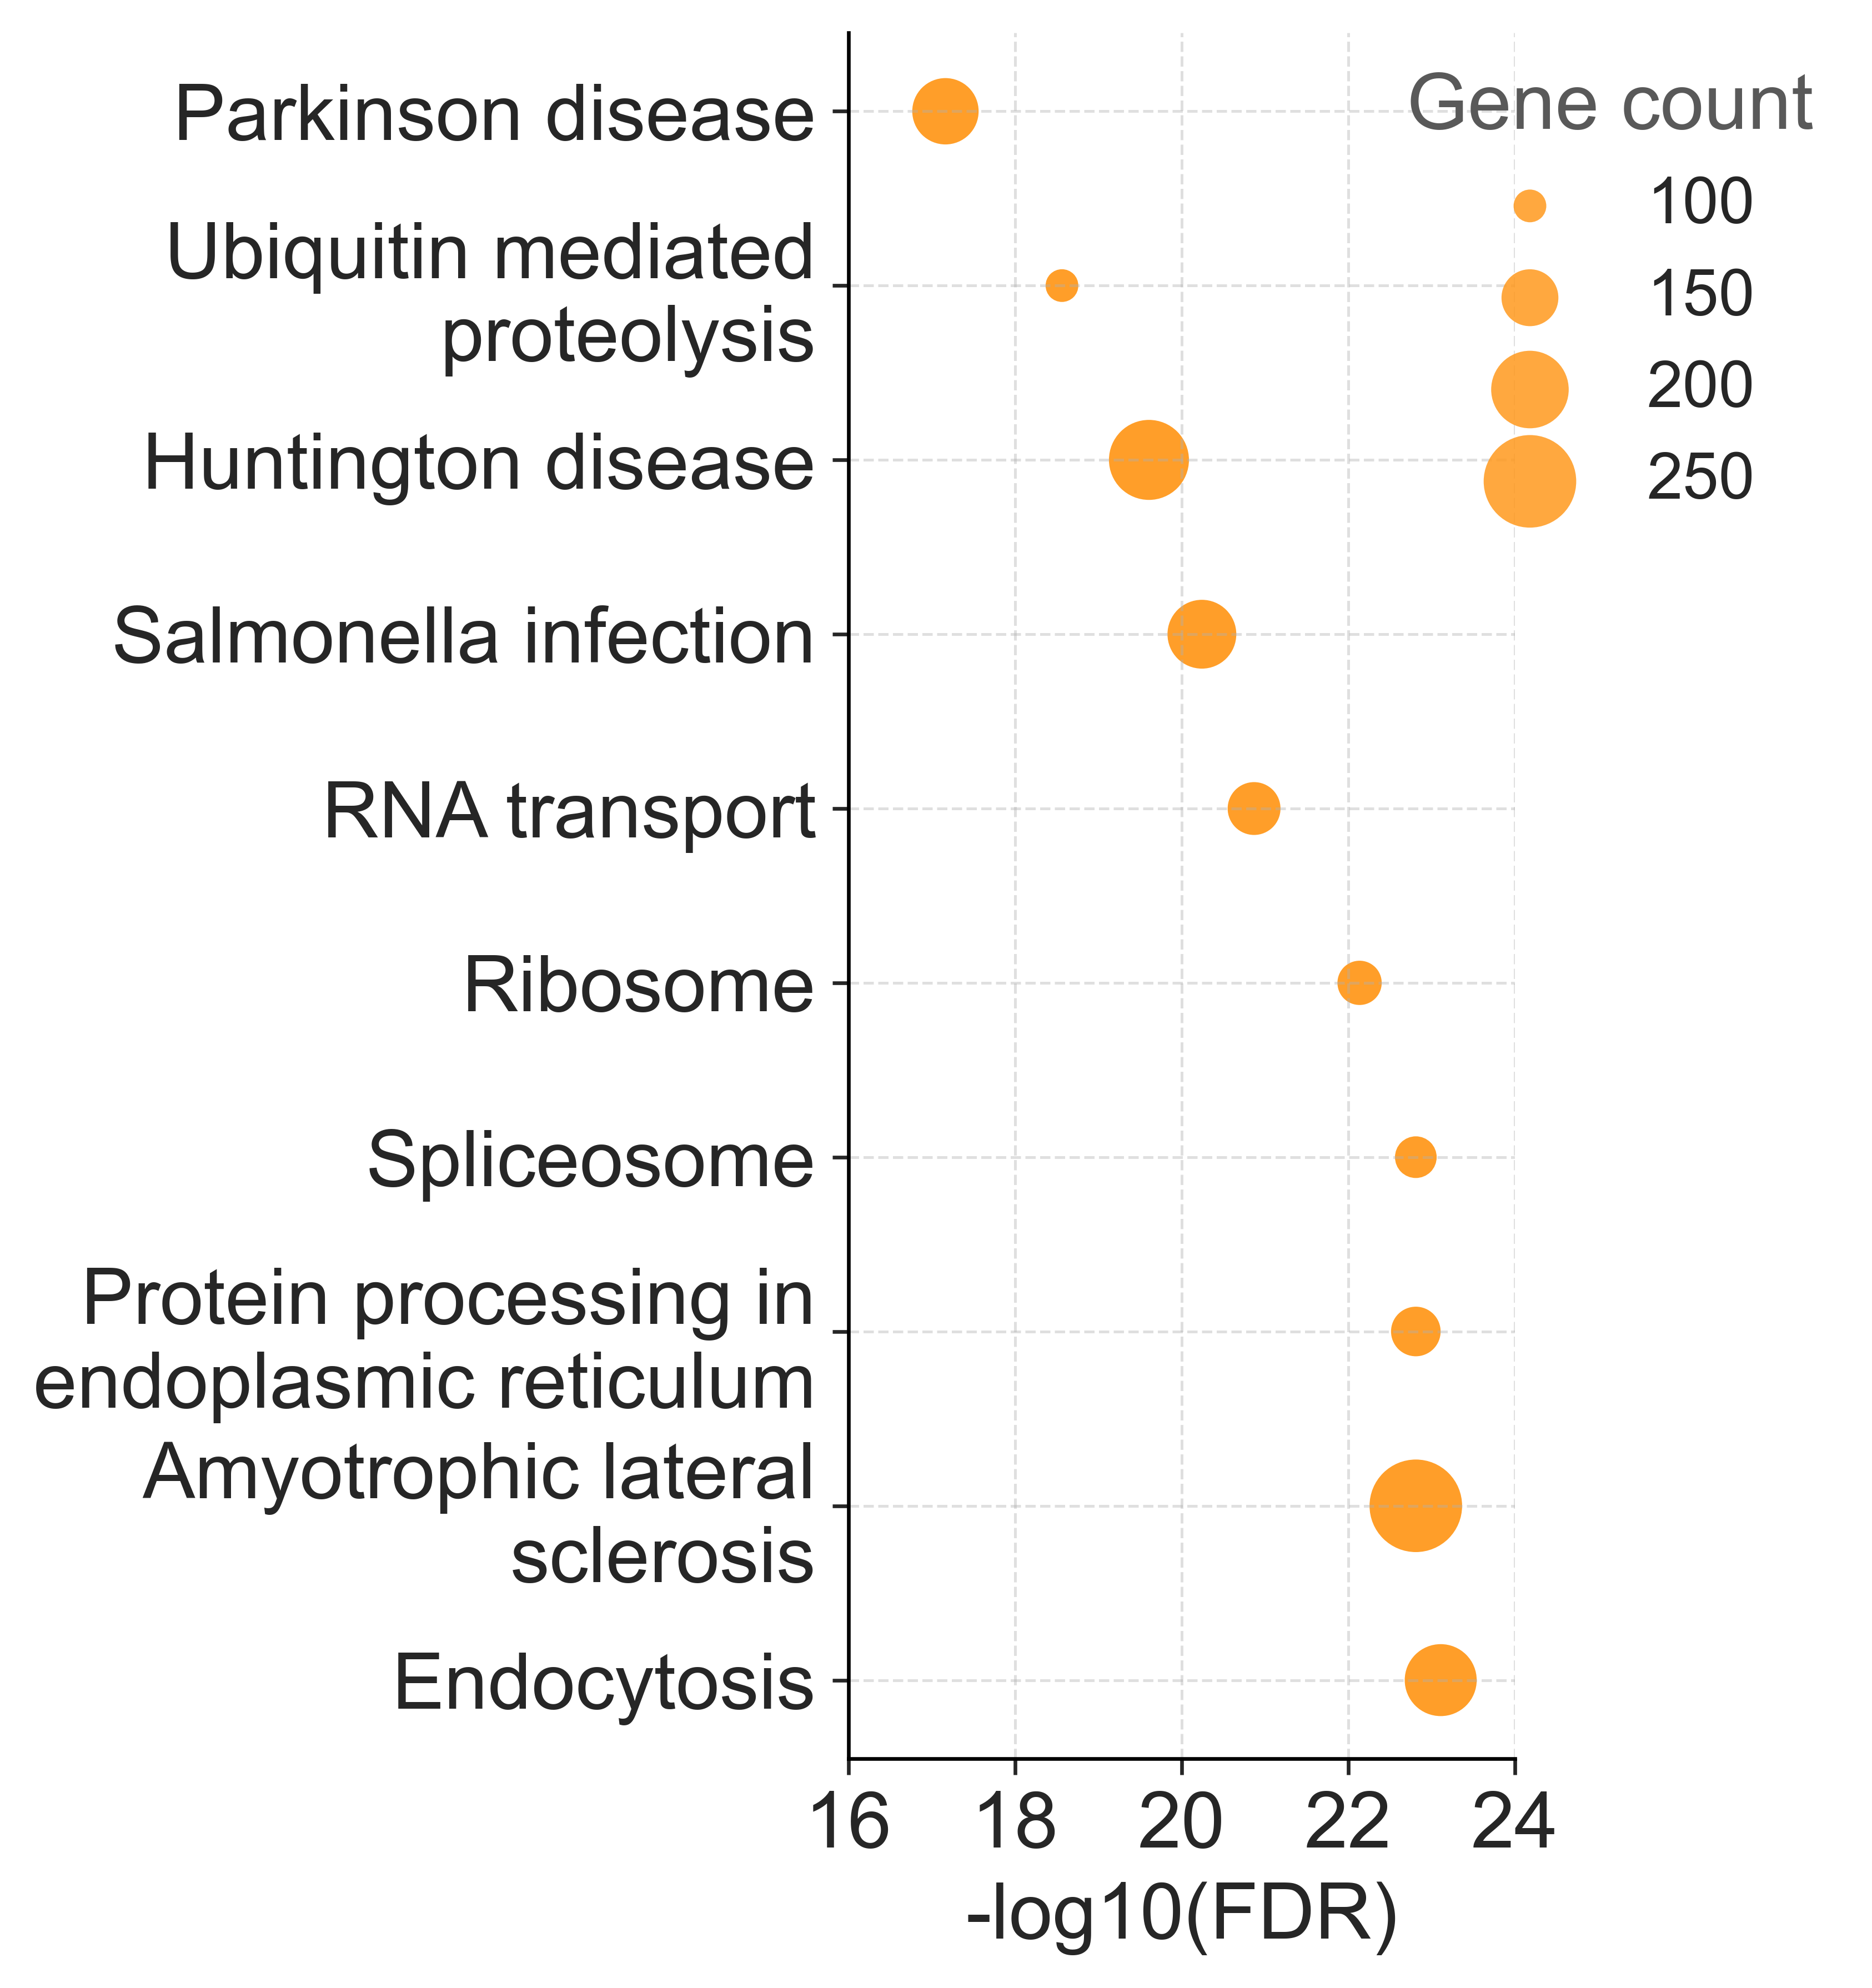

In [22]:
plot_topN_kegg2(
    res_kegg,
    N=10,
    gene_set="KEGG_2021_Human",
    term_col="Term",
    fdr_col="Adjusted P-value",
    overlap_col="Overlap",
    drop_go_id=True,
    figsize=(10, 6.1),
    ticksize=17,
    size_range=(50, 400),          # 气泡大小范围（面积）
    point_color="#FF991D",     #FF991D    # muted blue（科研风）#4E79A7
    text_color="#262626",
    grid=True,
)

In [34]:
# res_kegg[res_kegg["Gene_set"] == "KEGG_2021_Human" ].Term.tolist()

In [24]:
# plot_topN_kegg(
#     res_kegg,
#     N=10,
#     gene_set="KEGG_2021_Human",
#     term_col="Term",
#     fdr_col="Adjusted P-value",
#     overlap_col="Overlap",
#     drop_go_id=True,
#     figsize=(8, 6),
#     ticksize = 20
# )

# GO enrichment 

In [25]:


go_libs = [
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
    "GO_Cellular_Component_2023",
]

enr_GO = gp.enrichr(
        gene_list= genes,
        gene_sets= go_libs,
        organism= "human",
        outdir= None,
        cutoff= 0.05,  # adj p-value阈值
    )

# results table
res_go = enr_GO.results
print(res_go.head())

                     Gene_set  \
0  GO_Biological_Process_2023   
1  GO_Biological_Process_2023   
2  GO_Biological_Process_2023   
3  GO_Biological_Process_2023   
4  GO_Biological_Process_2023   

                                                Term  Overlap       P-value  \
0                           Translation (GO:0006412)  223/234  7.402426e-73   
1                       Gene Expression (GO:0010467)  257/296  5.353767e-62   
2        mRNA Splicing, Via Spliceosome (GO:0000398)  190/211  1.230384e-51   
3                       mRNA Processing (GO:0006397)  192/214  1.423084e-51   
4  RNA Splicing, Via Transesterification Reaction...  163/180  3.037646e-45   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0      3.889975e-69            0                     0   30.450150   
1      1.406702e-58            0                     0    9.917288   
2      1.869576e-48            0                     0   13.521817   
3      1.869576e-48            0              

In [6]:
# res_go.to_csv(f'{file_path_kegg}\GO_enrich_allgenes_csv')
res_go = pd.read_csv(f'{file_path_kegg}\GO_enrich_allgenes_csv')

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_topN_go(
    res,
    N=20,
    gene_set="GO_Cellular_Component_2023",
    term_col="Term",
    fdr_col="Adjusted P-value",
    overlap_col="Overlap",
    drop_go_id=True,
    figsize=(8, 10),
    ticksize=18,
    size_range=(80, 900),          # 气泡大小范围（面积）
    point_color="#4E79A7",         # muted blue（科研风）
    text_color="gray",
    grid=True,
    xmin = 20, 
    xmax = 300
):
    df = res.copy()

    # filter by gene set library if possible
    if gene_set is not None and "Gene_set" in df.columns:
        df = df[df["Gene_set"] == gene_set].copy()

    # remove trailing "(GO:xxxxxxx)" safely (no regex)
    if drop_go_id and term_col in df.columns:
        df[term_col] = df[term_col].astype(str).str.split(" (GO:", regex=False).str[0]

    # ensure numeric FDR
    if fdr_col not in df.columns:
        raise ValueError(f"Column {fdr_col!r} not found. Available columns: {df.columns.tolist()}")

    df[fdr_col] = pd.to_numeric(df[fdr_col], errors="coerce")
    df = df.dropna(subset=[fdr_col]).copy()

    # top N by FDR
    df = df.sort_values(fdr_col, ascending=True).head(N).copy()
    df["neglog10_FDR"] = -np.log10(df[fdr_col].clip(lower=1e-300))

    # robust gene count extraction from Overlap like "5/120"
    if overlap_col in df.columns:
        df["Gene_count"] = (
            df[overlap_col].astype(str).str.extract(r"(\d+)\s*/", expand=False)
        )
        df["Gene_count"] = pd.to_numeric(df["Gene_count"], errors="coerce")

    # drop rows with no Gene_count (optional but usually helpful)
    df = df.dropna(subset=["Gene_count"]).copy()

    # ---- order: make most significant on TOP ----
    # most significant = larger -log10(FDR)
    df = df.sort_values("neglog10_FDR", ascending=False).copy()

    # convert y to categorical and preserve order
    df[term_col] = pd.Categorical(df[term_col], categories=df[term_col].tolist(), ordered=True)
    # ---- before plotting: wrap y labels ----
    df[term_col] = df[term_col].astype(str).apply(
        lambda s: "\n".join(textwrap.wrap(s, width=28, break_long_words=False))
    )

    # ---- map Gene_count -> bubble area ----
    gc = df["Gene_count"].astype(float).values
    gc_min, gc_max = np.nanmin(gc), np.nanmax(gc)
    if gc_min == gc_max:
        sizes = np.full_like(gc, np.mean(size_range), dtype=float)
    else:
        sizes = np.interp(gc, (gc_min, gc_max), size_range)

    # ---- plot ----
    plt.rcParams["font.family"] = "Arial"
    fig, ax = plt.subplots(figsize=figsize, dpi=600)

    ax.scatter(
        df["neglog10_FDR"],
        df[term_col],
        s=sizes,
        alpha=0.95,
        color=point_color,
        edgecolors="none"
    )

    ax.set_xlabel("-log10(FDR)", fontsize=ticksize, color=text_color)
    ax.set_ylabel("", fontsize=ticksize, color=text_color)

    ax.set_xlim(xmin, xmax)
    ax.set_xticks(np.arange(xmin, xmax, 100)) 

    ax.tick_params(axis="x", labelsize=ticksize, colors=text_color)
    ax.tick_params(axis="y", labelsize=ticksize, colors=text_color)

    # optional: light y-grid
    if grid:
        ax.grid(True, axis="both", linestyle="--", linewidth=0.6, alpha=0.4)

    # ---- clean spines ----
    # for spine in ax.spines.values():
    #     spine.set_visible(True)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ---- manual size legend (clean, no overlap) ----
    # ---- pick "nice" legend values like 100/150/200 ----
    step = 50  # 你想要 100/150/200 这种，就用 50；想要 100/200/300 用 100
    
    lo = int(np.floor(gc_min / step) * step)
    hi = int(np.ceil(gc_max / step) * step)
    
    reps = np.arange(lo, hi + step, step).astype(int)
    
    # 如果 reps 太多，只取 3~4 个均匀分布的
    max_items = 4
    if len(reps) > max_items:
        idx = np.linspace(0, len(reps) - 1, max_items).round().astype(int)
        reps = reps[idx]
    
    # 去掉非正数（可选：如果你不想出现 0）
    reps = reps[reps > 0]
    if gc_min != gc_max:
        rep_sizes = np.interp(reps, (gc_min, gc_max), size_range)
    else:
        rep_sizes = np.full_like(reps, np.mean(size_range), dtype=float)

    handles = [
        ax.scatter([], [], s=rs, color=point_color, alpha=0.85, edgecolors="none")
        for rs in rep_sizes
    ]
    labels = [f"{r}" for r in reps]

    leg = ax.legend(
        handles, labels,
        title="Gene count",
        frameon=False,                 # no legend frame
        fontsize=ticksize,
        title_fontsize=ticksize,
        loc="center left",
        bbox_to_anchor=(0.75, 0.85)
    )
    # legend text color / font
    for t in leg.get_texts():
        t.set_color(text_color)
        t.set_fontfamily("Arial")
    leg.get_title().set_color("#595959")
    leg.get_title().set_fontfamily("Arial")

    plt.tight_layout()
    plt.gcf().subplots_adjust(left=0.55, right=0.75)  # 你可以微调这两个数
    
    plt.show()
    # return df

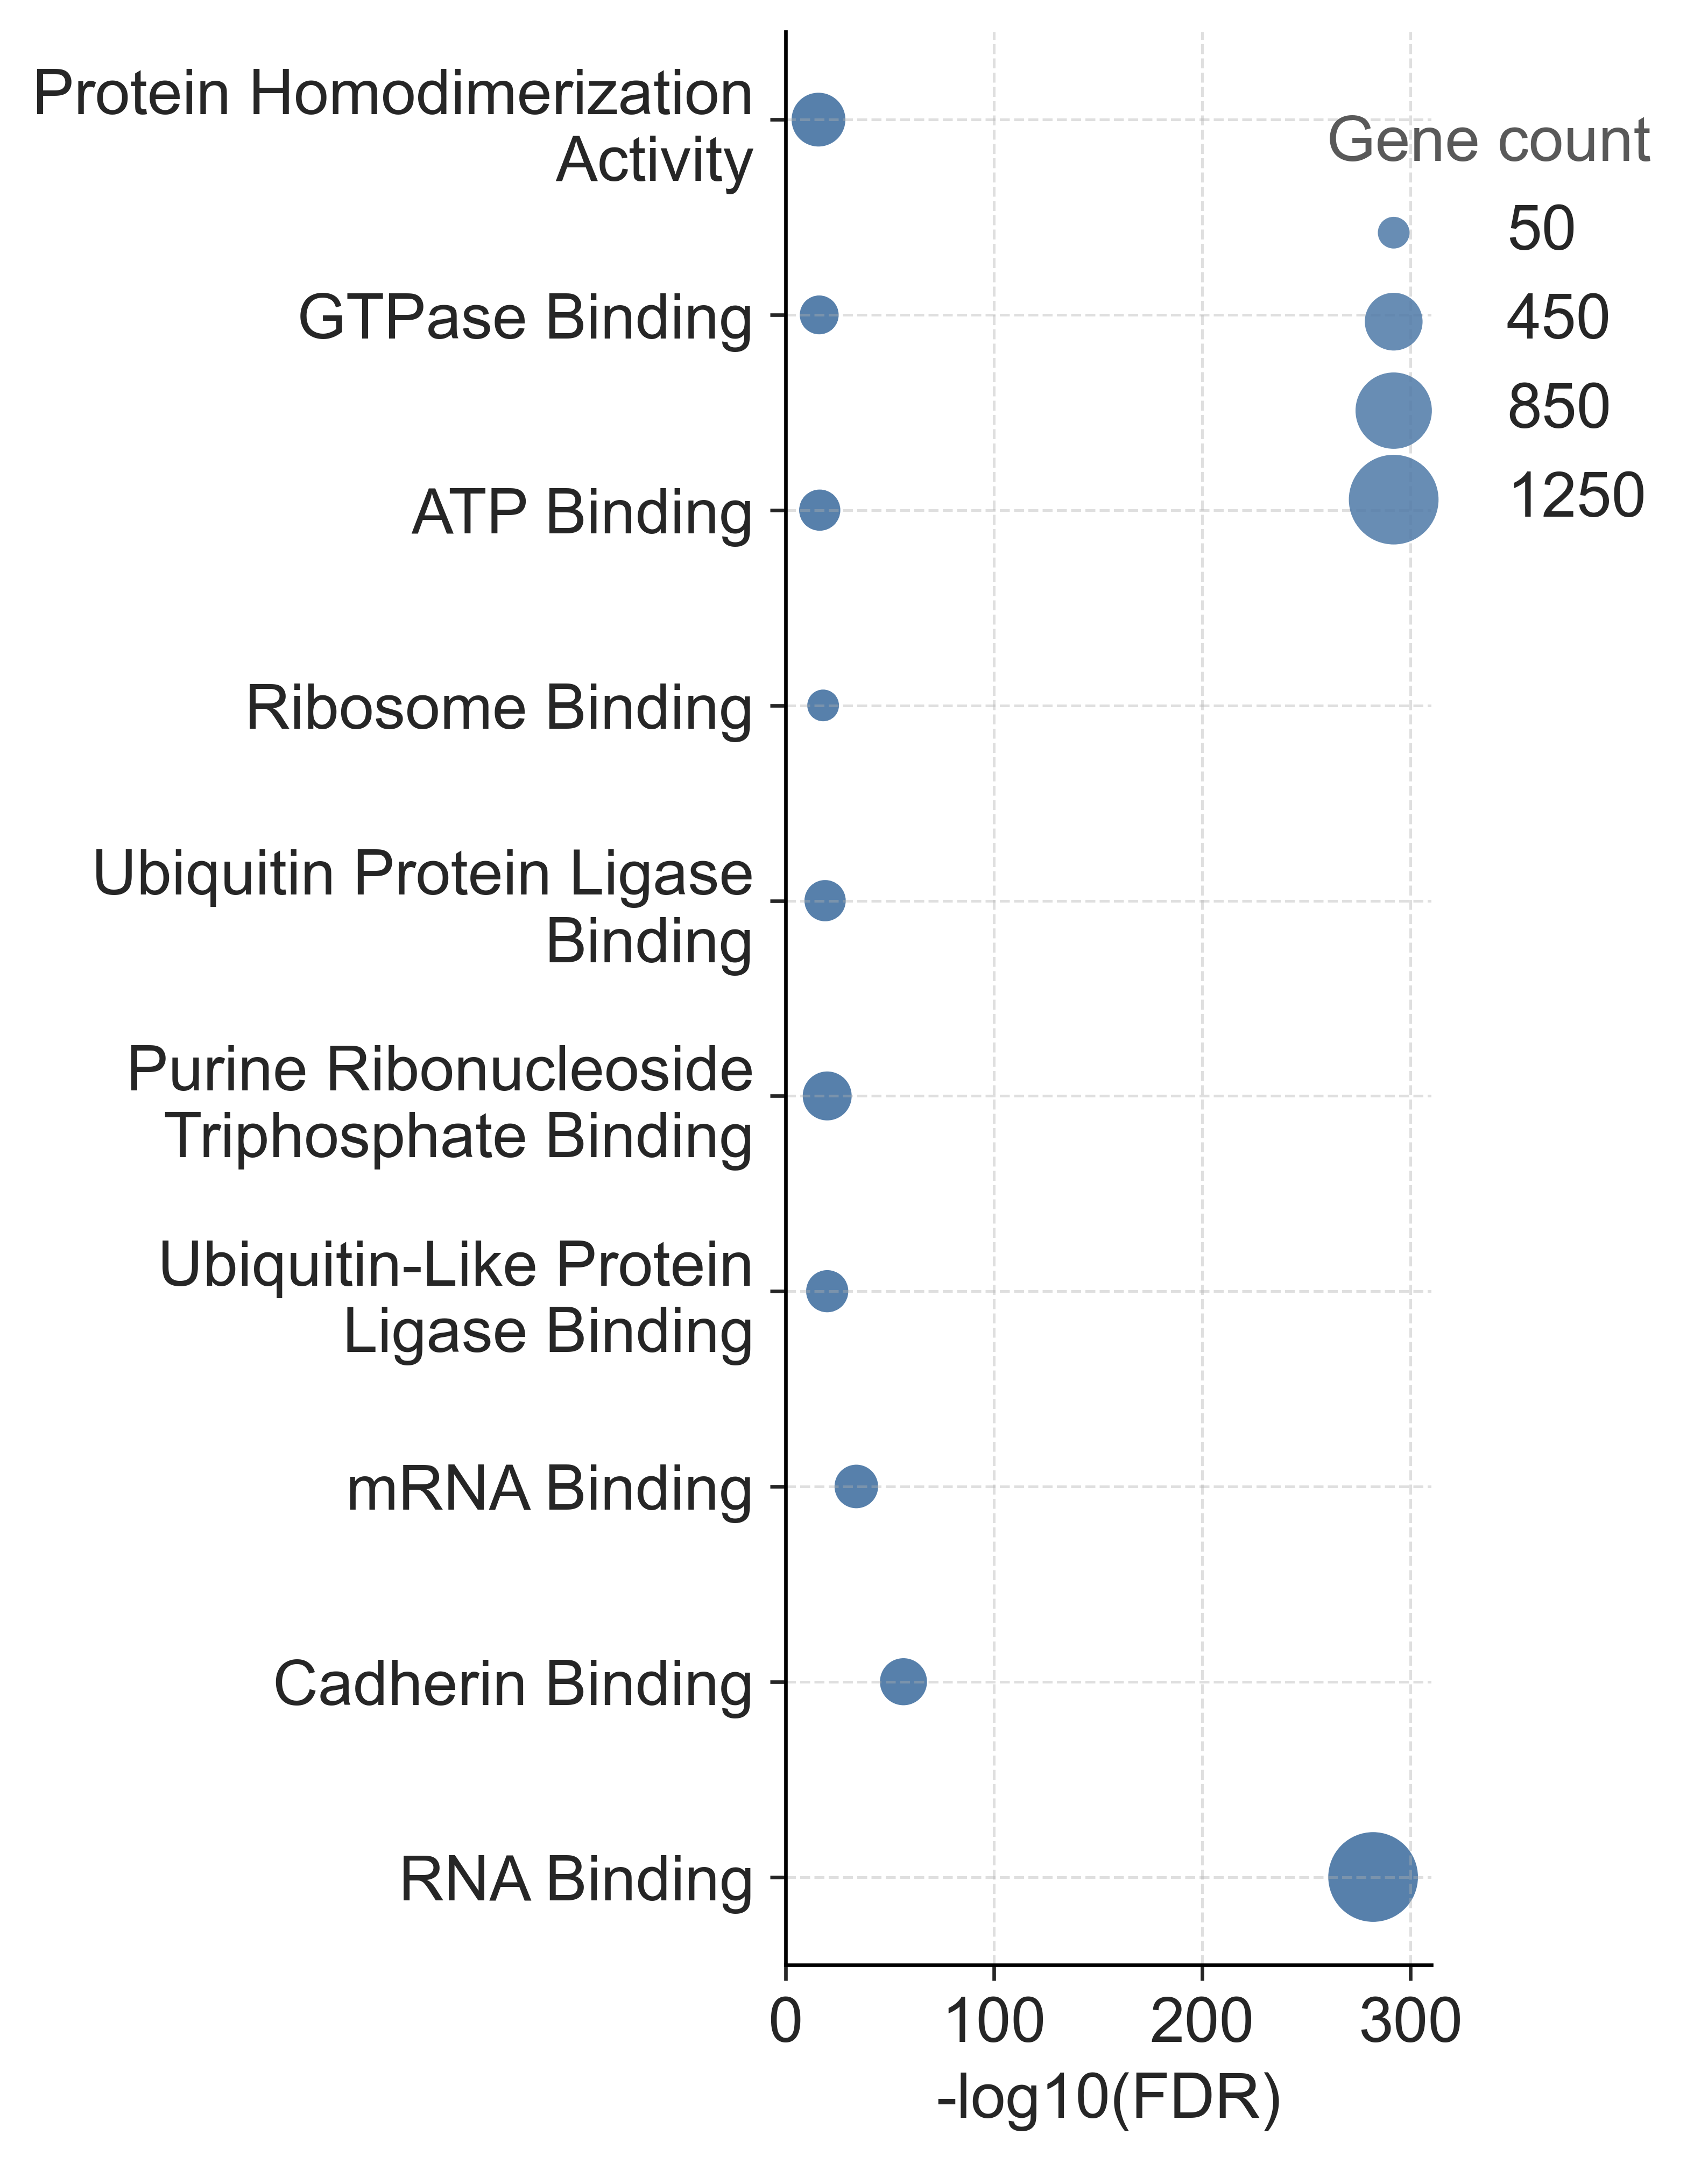

In [13]:
go_libs = [
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
    "GO_Cellular_Component_2023",
]

plot_topN_go(
    res_go,
    N=10,
    gene_set="GO_Molecular_Function_2023",
    term_col="Term",
    fdr_col="Adjusted P-value",
    overlap_col="Overlap",
    drop_go_id=True,
    figsize=(10, 6.8),
    ticksize=14,
    size_range=(50, 400),          # 气泡大小范围（面积）
    point_color="#4E79A7",     #FF991D    # muted blue（科研风）#4E79A7
    text_color="#262626",
    grid=True,
    xmin = 0, 
    xmax = 310
)